# **Introdução** 

### Contexto

O serviço de telefonia virtual CallMeMaybe está desenvolvendo uma nova funcionalidade que permitirá aos supervisores **identificar operadores menos eficientes**.

Os clientes da empresa são **organizações que precisam gerenciar grandes volumes de chamadas** — tanto recebidas quanto realizadas por diversos operadores.

De acordo com as regras de negócio, um operador é considerado **ineficiente** se:

- Possui **muitas chamadas recebidas perdidas** (internas ou externas);
- Apresenta **tempo de espera prolongado** nas chamadas recebidas;
- E, no caso de operadores responsáveis por chamadas de saída, realiza **poucas chamadas ativas**.

### Dados

O dataset compactado **`telecom_dataset_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID da conta do cliente
- **`date`**: data em que as estatísticas foram coletadas
- **`direction`**: “direção” da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**)
- **`internal`**: indica se a chamada foi **interna** (entre operadores de um mesmo cliente)
- **`operator_id`**: identificador do operador
- **`is_missed_call`**: indica se foi uma **chamada perdida**
- **`calls_count`**: número de chamadas
- **`call_duration`**: duração da chamada (sem incluir o tempo de espera)
- **`total_call_duration`**: duração total da chamada (incluindo o tempo de espera)
O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

### Objetivo 

O objetivo desta análise será identificar operadores com padrões abaixo do esperado com base em seu desempenho, sob a perspectiva de três métricas principais: chamadas perdidas, tempo de espera, e volume de chamadas outbound.  

# **Setup e Dados**

## Ambiente

### Importação bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as mp
from scipy import stats as st

### Configurações Globais

In [2]:
# reprodutibilidade — seed único
RANDOM_STATE = 42

# exibição de dados
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

### Carregamento de dados

In [3]:
# leitura arquivo CSV
telecom_raw = pd.read_csv('../data/raw/telecom_dataset_new.csv')

In [4]:
# leitura arquivo CSV
clients_raw = pd.read_csv('../data/raw/telecom_clients.csv')

## Pré Processamento 

### Primeiras impressões

#### *Telecom*

In [5]:
# primeira visualização
telecom_raw.head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


In [6]:
# descoberta informações sobre o dataframe
telecom_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


O dataset *telecom* possui a nomenclatura de suas colunas dentro do padrão snake_case. 

Encontram-se valores ausentes nas colunas `internal` e `operator_id`. 

Seria mais adequado mudança no tipo de dado em colunas como `date` para `datetime` visando operações com datas, e `operator_id` e `user_id` para `str` por serem identificadores e não propriamente um valor numérico para cálculos.

#### *Clients*

In [7]:
# primeira visualização
clients_raw.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [8]:
# descoberta informações sobre o datafrane  
clients_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


O dataset *clients* possui a nomenclatura de suas colunas dentro do padrão snake_case.

Não encontram-se valores ausentes.

Seria mais adequado mudança no tipo de dado na coluna `date_start` para `datetime`, visando operações com datas e `user_id` para `str` visando consitência.

### Tratamento de valores duplicados

In [9]:
# criação de cópias
telecom = telecom_raw.copy()
clients = clients_raw.copy()

In [10]:
# descoberta quantidade de valores duplicados
print(f'Número de registros duplicados no dataframe Telecom: {telecom.duplicated().sum()}')
print(f'Número de registros duplicados no dataframe Clients: {clients.duplicated().sum()}')

Número de registros duplicados no dataframe Telecom: 4900
Número de registros duplicados no dataframe Clients: 0


In [11]:
# visualização de registros duplicados
telecom[telecom.duplicated()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.00,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.00,False,11,1413,1473
...,...,...,...,...,...,...,...,...,...
53869,168601,2019-11-25 00:00:00+03:00,in,False,952914.00,False,7,1229,1282
53874,168601,2019-11-26 00:00:00+03:00,in,False,952914.00,False,4,539,562
53875,168601,2019-11-26 00:00:00+03:00,in,False,NaN,True,3,0,35
53885,168603,2019-11-20 00:00:00+03:00,out,False,959118.00,True,3,0,89


In [12]:
# visualização amostra registros de um operador aleatório
telecom_raw[telecom_raw['operator_id'] == 880020.00]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
11,166377,2019-08-06 00:00:00+03:00,out,False,880020.00,True,5,0,70
13,166377,2019-08-06 00:00:00+03:00,out,False,880020.00,False,5,800,819
16,166377,2019-08-07 00:00:00+03:00,out,False,880020.00,False,2,232,240
76,166377,2019-08-22 00:00:00+03:00,in,False,880020.00,False,1,33,49
124,166377,2019-09-02 00:00:00+03:00,out,True,880020.00,True,2,0,0


In [13]:
# remoção dados duplicados
telecom = telecom.drop_duplicates().reset_index(drop=True)

**Decisão Metodológica**: remoção de duplicatas.

4.900 linhas duplicadas identificadas (~9% do dataset original de 53.902 linhas). 

Critério: linha completamente idêntica em todas as 9 colunas. 

Dataset após limpeza: 49.002 linhas.

Cada linha representa um agregado por combinação única de (`user_id`, `date`, `direction`, `internal`, `operator_id`, `is_missed_call`). 

Dentro desta estrutura, dois registos com valores idênticos em todas as colunas são impossíveis como dado legítimo — confirmado na inspeção do operador 880020 (índices 6 e 8: linha idêntica em todas as 9 colunas).

### Tratamento de valores nulos

In [14]:
# descoberta quantidade registros ausentes dataset telecom
telecom.isnull().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Valores nulos em duas colunas: `internal` e `operator_id`.

In [15]:
# descoberta quantidade registros ausentes dataset clients
clients.isnull().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [16]:
# visualização de registros ausentes na coluna internal
telecom[telecom['internal'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
917,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
996,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1705,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1761,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.00,False,1,2,9
5645,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.00,False,1,393,423
...,...,...,...,...,...,...,...,...,...
47702,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
47819,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
47844,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
48837,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


In [17]:
# visualização de registros ausentes na coluna operator_id
telecom[telecom['operator_id'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
16,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
26,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
...,...,...,...,...,...,...,...,...,...
48978,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39
48982,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19
48990,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30
48994,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121


In [18]:
# contagem de chamadas perdidas dentre os operadores não identificados
telecom[telecom['operator_id'].isnull()]['is_missed_call'].value_counts()

is_missed_call
True     7343
False     113
Name: count, dtype: int64

A maioria esmagadora (~98,5%) de valores nulos na coluna `operator_id` são referentes a chamadas perdidas. 

In [19]:
# contagem de chamadas inbound dentre os operadores não identificados
telecom[telecom['operator_id'].isnull()]['direction'].value_counts()

direction
in     7270
out     186
Name: count, dtype: int64

A maioria esmagadora (~97,5%) de valores nulos na coluna `operator_id` são referentes a chamadas inbound.

In [20]:
telecom[telecom['is_missed_call'] == True].shape[0]

21453

Um volume infímo de 110 chamadas (~0,22%) não possuem identificação se foram entre operadores de um mesmo cliente.

Cerca de 34,2% do total de chamadas perdidas do dataset não possuem operador identificado.

Padrão consistente com chamadas que chegaram ao sistema mas nunca foram atribuídas a um operador.

**DECISÃO METODOLÓGICA**:
manutenção de registros de chamada sem operador atrelado e identificação se foram entre operadores de um mesmo cliente.

Das 7.456 linhas com `operator_id` nulo:
- 7.270 (~97.5%) são chamadas inbound
- 7.343 (~98.5%) têm `is_missed_call = True`
- Representam 34.2% do total de chamadas perdidas do dataset (7.343 / 21.453)

Interpretação: chamadas que chegaram ao sistema mas nunca foram atribuídas a um operador — não existe operador a avaliar individualmente. Estas linhas são mantidas no dataset completo para preservar a taxa real de chamadas perdidas ao nível da empresa, mas são excluídas automaticamente nas análises por operador por ausência de `operator_id`.

### Alterações de tipos de dados

In [21]:
# conversões de indicadores para str
telecom['user_id']= telecom['user_id'].astype('str')
telecom['operator_id'] = telecom['operator_id'].astype(str).replace('nan', pd.NA)
clients['user_id'] = clients['user_id'].astype('str')

In [22]:
# conversões para datetime
telecom['date'] = pd.to_datetime(telecom['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

### Engenharia de features

In [23]:
# criação coluna tempo de espera
telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']
print(f"Registros com tempo de espera negativo: {(telecom['waiting_time'] < 0).sum()}")

Registros com tempo de espera negativo: 0


In [24]:
# criação coluna mês
telecom['month'] = telecom['date'].dt.month 

In [25]:
# criação coluna semana
telecom['week'] = telecom['date'].dt.isocalendar().week 

In [26]:
# criação dataframe agregado entre duas tablas base
telecom_merged = telecom.merge(
    clients, 
    on='user_id',
    how='left'
)

In [27]:
# filtro para análise sem dados nulos
telecom_ops = telecom_merged[telecom_merged['operator_id'].notna()].copy()
telecom_ops = telecom_ops[telecom_ops['internal'].notna()].copy()

# **EDA**

### Investigação variáveis chave

#### Tempo de espera

In [28]:
# descoberta características variável chave tempo de espera
telecom_ops['waiting_time'].describe()

count   41491.00
mean      312.21
std      1176.10
min         0.00
25%        19.00
50%        60.00
75%       219.00
max     46474.00
Name: waiting_time, dtype: float64

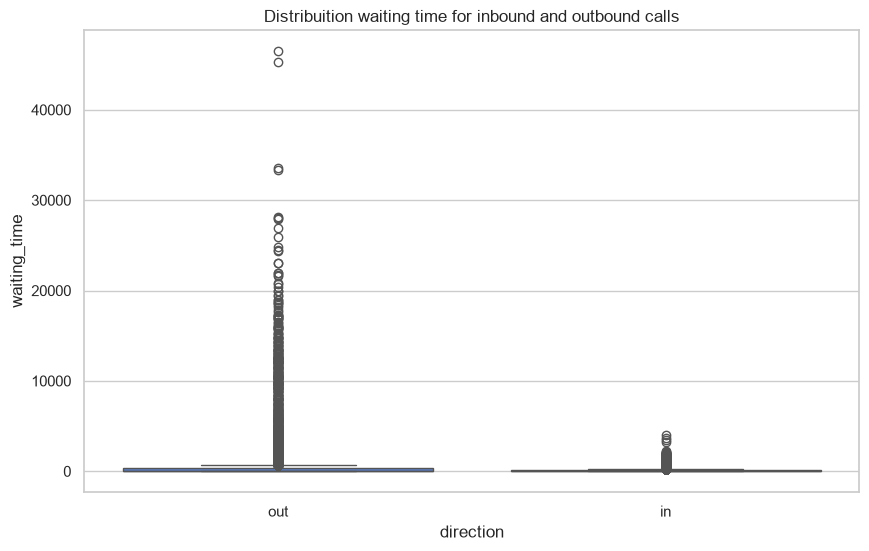

In [29]:
# criação boxplot para visualização variável contínua
sns.boxplot(
    data=telecom_ops, 
    x='direction', 
    y='waiting_time'
)
plt.title('Distribuition waiting time for inbound and outbound calls')
plt.show()

In [30]:
# descoberta características tempo de espera para chamadas inbound
telecom_ops[telecom_ops['direction'] == 'in']['waiting_time'].describe()

count   12678.00
mean       97.20
std       185.59
min         0.00
25%        17.00
50%        38.00
75%        97.00
max      3998.00
Name: waiting_time, dtype: float64

A distribuição é fortemente assimétrica à direita na distriuição da variável alvo `waiting_time`, tanto em chamadas inbound e outbound. 

A maioria dos registros tem tempos de espera relativamente curtos, enquanto uma minoria de registros apresenta tempos de espera extremamente longos, gerando valores atípicos na cauda superior da distribuição.

Os outliers outbound atingem valores ~10x superiores aos inbound (máximo outbound ~46.000s, máximo inbound ~4.000s).

#### Contagem de chamadas

In [31]:
# descoberta características variável chave contagem de chamadas
telecom_ops['calls_count'].describe()

count   41491.00
mean       16.92
std        59.79
min         1.00
25%         1.00
50%         4.00
75%        14.00
max      4817.00
Name: calls_count, dtype: float64

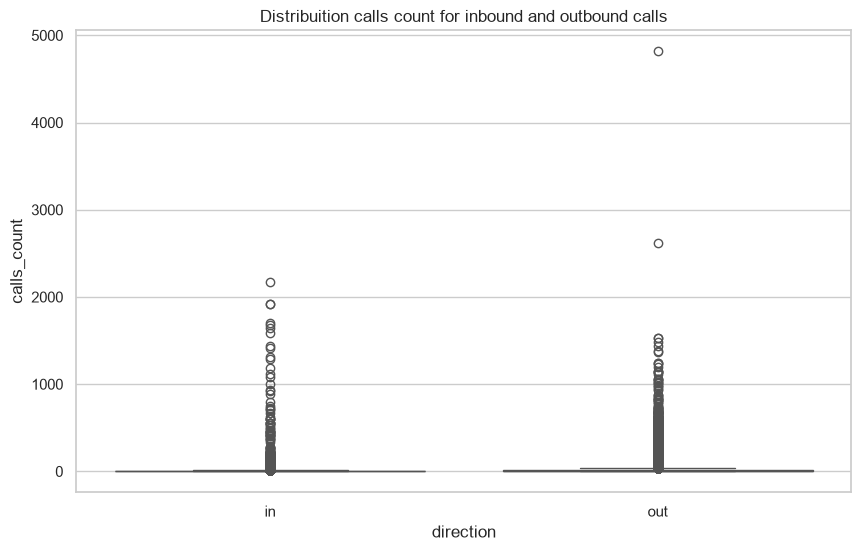

In [32]:
# criação boxplot para variável contínua
sns.boxplot(
    data=telecom, 
    x='direction', 
    y='calls_count'
)
plt.title('Distribuition calls count for inbound and outbound calls')
plt.show()

In [33]:
# descoberta características contagem de chamadas para outbound
telecom_ops[telecom_ops['direction'] == 'out']['calls_count'].describe()

count   28813.00
mean       21.11
std        70.64
min         1.00
25%         2.00
50%         5.00
75%        18.00
max      4817.00
Name: calls_count, dtype: float64

A distribuição é fortemente assimétrica à direita na distriuição da variável alvo `calls_count`, tanto em chamadas inbound e outbound. 

A maioria das observações envolve apenas algumas chamadas, enquanto um número pequeno de registos apresenta volumes de chamadas excepcionalmente elevados, gerando numerosos valores atípicos na cauda superior da distribuição.

Dentro das chamada outbound valor máximo atinge 4817 chamadas, apesar de a mediana ser de apenas 5.

#### Chamadas perdidas

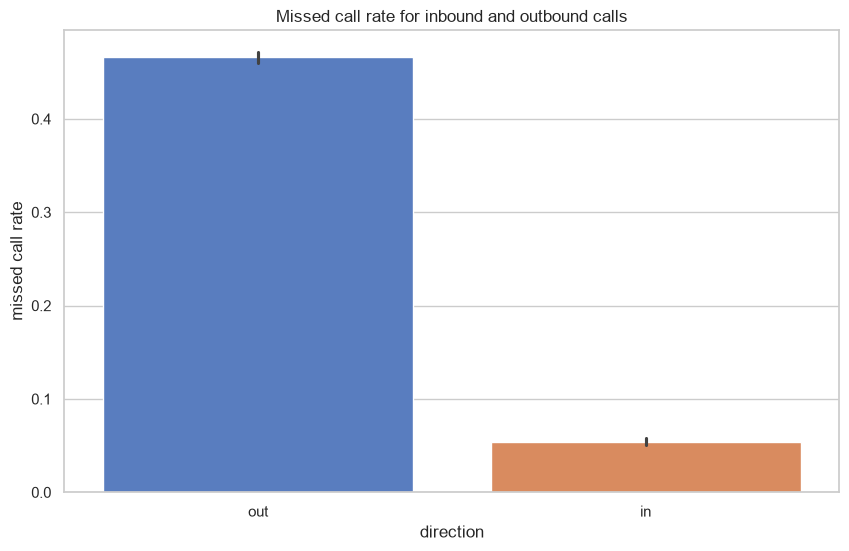

In [34]:
# criação gráfico de barras para variável categórica
sns.barplot(
    data=telecom_ops,
    x='direction',
    y='is_missed_call',
    hue='direction'
)
plt.title('Missed call rate for inbound and outbound calls')
plt.ylabel('missed call rate')
plt.show()

As chamadas inbound apresentam um desequilíbrio acentuado no que diz respeito à variável-alvo `is_missed_call`. 

A maioria das chamadas inbound foi atendida, enquanto as chamadas perdidas representam apenas uma pequena fração das observações (~5%). 

Em contrapartida, as chamadas outbound apresentam uma distribuição muito mais equilibrada entre chamadas atendidas e chamadas perdidas (~45%).

A taxa outbound elevada pode reflectir comportamento normal de contacto (destinatário não atende). Por esta razão, a avaliação de operadores é calculado exclusivamente sobre chamadas inbound.

### Volumes temporais

In [35]:
telecom_ops['month'].unique()

array([ 8,  9, 10, 11], dtype=int32)

O período de registros do dataset cobre os meses de Agosto, Setembro, Outubro e Novembro.

#### Volume semanal de chamadas

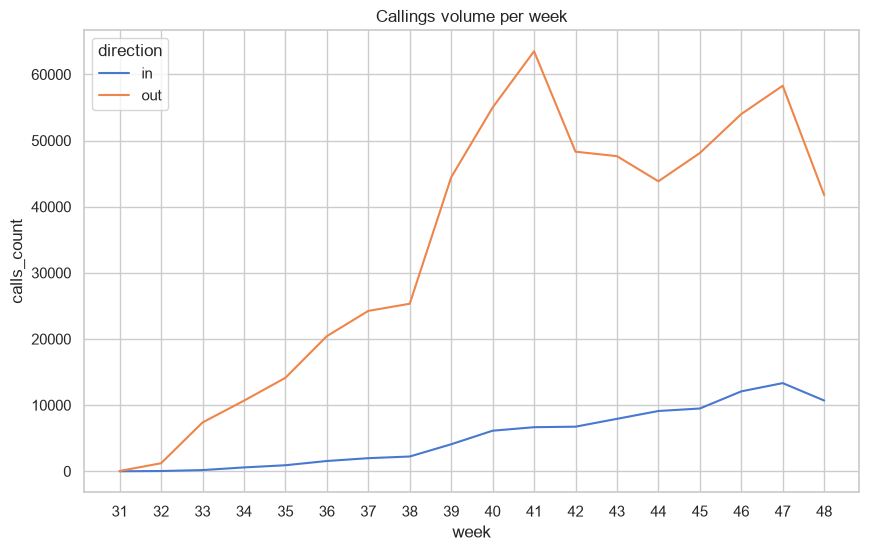

In [36]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=telecom_ops.groupby(['week', 'direction'])['calls_count'].sum().reset_index(), x='week', y='calls_count', hue='direction')
plt.title('Callings volume per week')
plt.xticks(telecom['week'].unique())
plt.show()

É notável o crescimento do volume de chamadas registrados durante o período de observação.  

Enquanto as chamadas outbound tem crescimento acelerado, as chamadas inbound seguiu ritmo mais lento (outbound ~40.000 x ~10.000 inbound ao fim do período de observação).

#### Volume semanal de operadores

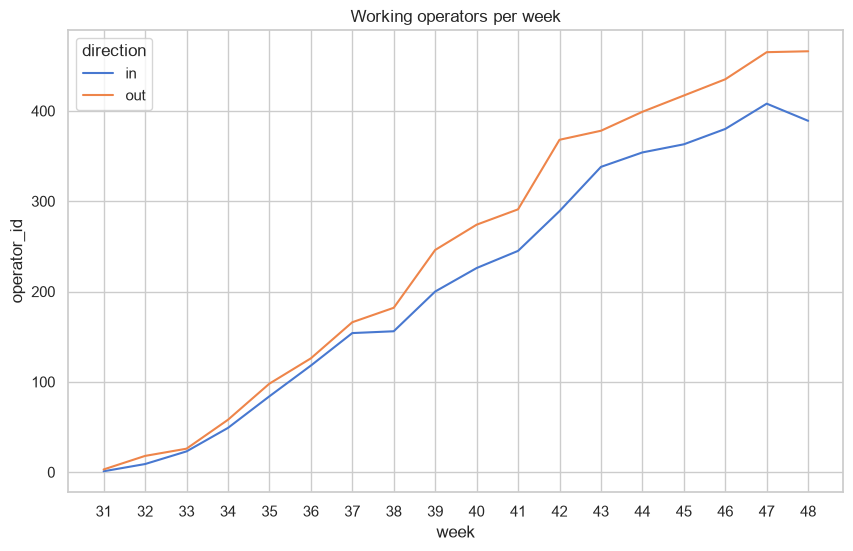

In [37]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=telecom_ops.groupby(['week', 'direction'])['operator_id'].nunique().reset_index(), x='week', y='operator_id', hue='direction')
plt.title('Working operators per week')
plt.xticks(telecom_ops['week'].unique())
plt.show()

É notável o crescimento do volume de operadores registrados durante o período de observação.  

Contudo, diferente do que foi observado no volume de chamadas, o número de operadores de outbound e inbound cresceram numa proporção similar.

#### Volume semanal de chamadas inbound perdidas

In [38]:
# criação agregado semanal chamadas inbound
weekly_inbound_ratio = (
    telecom_ops[
        telecom_ops['direction'] == 'in'
    ]
    .groupby('week')['calls_count']
    .sum()
    .reset_index()
)

In [39]:
# contagem de chamadas inbound perdidas
missed_inbound_calls = (
    telecom_ops[
        (telecom_ops['direction'] == 'in') &
        (telecom_ops['is_missed_call'] == True)
    ]
    .groupby('week', as_index=False)['calls_count']
    .sum()
    .rename(columns={'calls_count': 'missed_calls'})
)

In [40]:
# união resultado ao agregado
weekly_inbound_ratio = weekly_inbound_ratio.merge(
    missed_inbound_calls,
    on='week',
    how='left'
)

In [41]:
# criação coluna ratio 
weekly_inbound_ratio['missed_rate'] = weekly_inbound_ratio['missed_calls'] / weekly_inbound_ratio['calls_count'] 

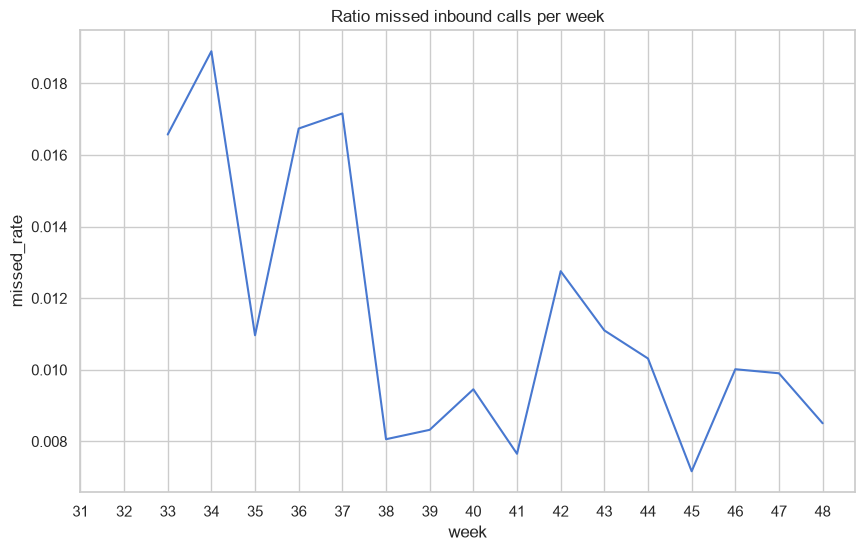

In [42]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=weekly_inbound_ratio, x='week', y='missed_rate')
plt.title('Ratio missed inbound calls per week')
plt.xticks(weekly_inbound_ratio['week'].unique())
plt.show()

A taxa de chamadas perdidas apresenta comportamento com tendência de queda com o avançar das semanas (de ~0.02% para ~0.01%) apesar do aumento no volume de chamadas.

### Investigação operadores

#### Distribuições volume de chamadas por operador 

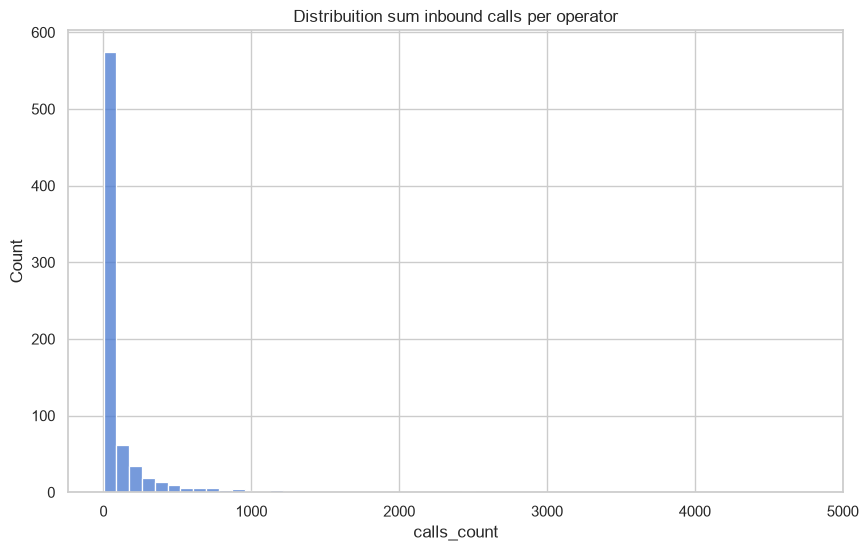

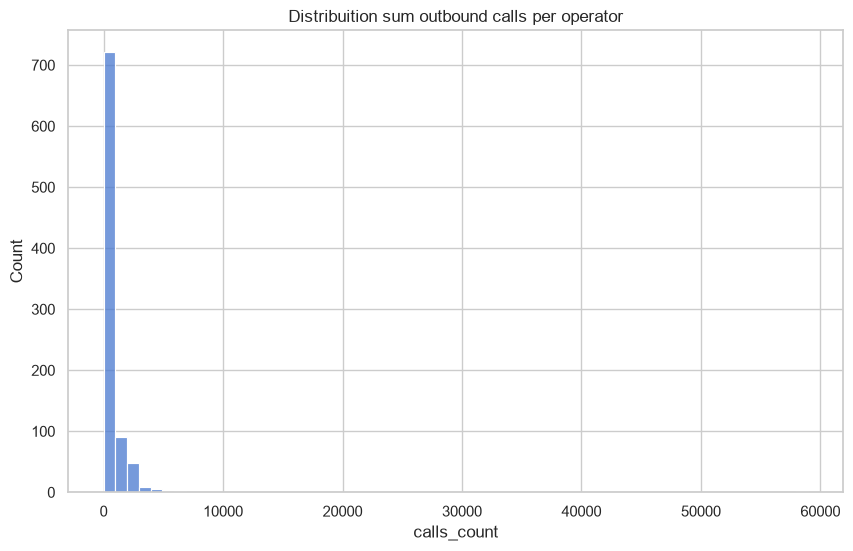

In [43]:
# visualização distribuição do número de chamadas por operador inbound
sns.histplot(telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['calls_count'].sum())
plt.title('Distribuition sum inbound calls per operator')
plt.show()

# visualização distribuição do número de chamadas por operador outboubd
sns.histplot(telecom_ops[telecom_ops['direction'] == 'out'].groupby('operator_id')['calls_count'].sum())
plt.title('Distribuition sum outbound calls per operator')
plt.show()

In [69]:
# visualização características soma de chamadas inbound por operador
telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['calls_count'].sum().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count    754.00
mean     124.33
std      356.29
min        1.00
25%        4.00
50%       17.00
75%       78.75
85%      184.05
90%      291.10
95%      590.25
max     4766.00
Name: calls_count, dtype: float64

In [ ]:
# visualização características da soma chamadas outbound por operador
telecom_ops[telecom_ops['direction'] == 'out'].groupby('operator_id')['calls_count'].sum().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count     882.00
mean      689.73
std      3122.95
min         1.00
25%        11.00
50%        90.00
75%       597.25
max     58977.00
Name: calls_count, dtype: float64

Volume de chamadas inbound: 
 * Metade dos 754 operadores possue volume inferior a 17 chamadas, enquanto no Q3 o valor está próximo de 78 (~4x superior a mediana).
 * O caso mais extremo é de um operador registrado com 4766 chamadas, um valor ~300x superior a mediana observada.

Volume de chamadas outbound: 
 * Metade dos 882 operadores possue volume inferior a 90 chamadas, enquanto no Q3 o valor está próximo de 597 (~6 superior a mediana).
 * O caso mais extremo é de um operador registrado com 58977 chamadas, um valor ~655x superior a mediana observada.

#### Volume de operadores por empresa

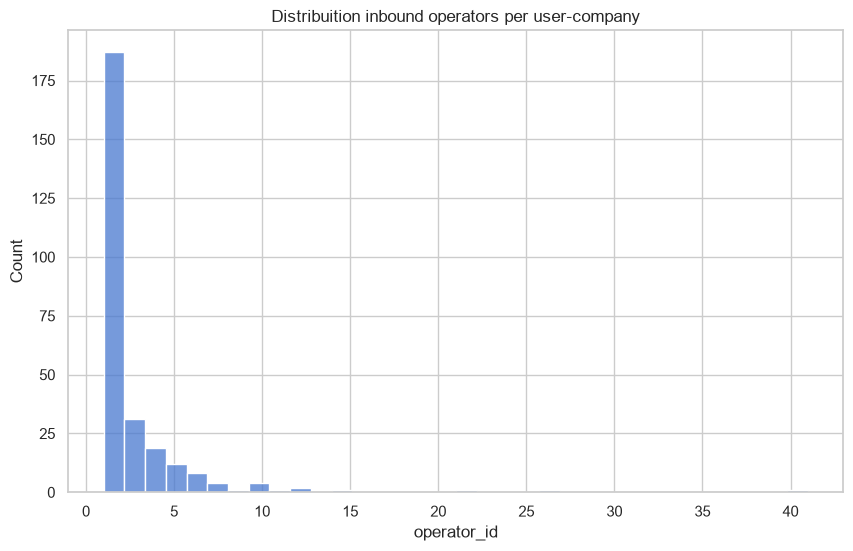

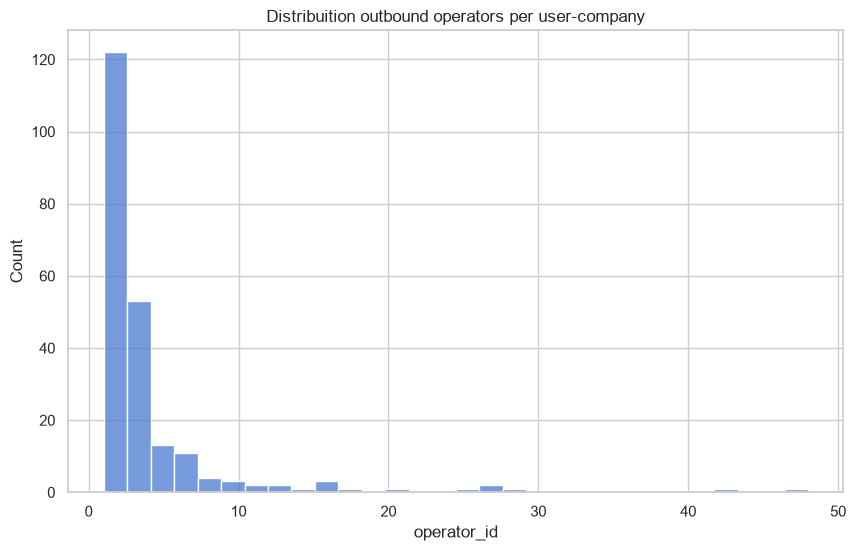

In [46]:
# visualização distribuição número de operadores inbound por empresa
sns.histplot(telecom_ops[telecom_ops['direction'] == 'in'].groupby('user_id')['operator_id'].nunique())
plt.title('Distribuition inbound operators per user-company')
plt.show()

# visualização distribuição número de operadores outbound por empresa
sns.histplot(telecom_ops[telecom_ops['direction'] == 'out'].groupby('user_id')['operator_id'].nunique())
plt.title('Distribuition outbound operators per user-company')
plt.show()

In [70]:
# visualização características número de operadores por empresa-cliente
telecom_ops[telecom_ops['direction'] == 'in'].groupby('user_id')['operator_id'].nunique().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count   273.00
mean      2.76
std       3.65
min       1.00
25%       1.00
50%       2.00
75%       3.00
85%       4.00
90%       5.00
95%       8.00
max      41.00
Name: operator_id, dtype: float64

In [71]:
# visualização características número de operadores por empresa-cliente
telecom_ops[telecom_ops['direction'] == 'out'].groupby('user_id')['operator_id'].nunique().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count   222.00
mean      3.97
std       5.97
min       1.00
25%       1.00
50%       2.00
75%       4.00
85%       5.85
90%       7.90
95%      13.95
max      48.00
Name: operator_id, dtype: float64

In [49]:
# contagem exata de empresas com apenas 1 operador inbound
telecom_ops[telecom_ops['direction'] == 'in'].groupby('user_id')['operator_id'].nunique().eq(1).sum()

np.int64(114)

In [50]:
# contagem exata de empresas com apenas 1 operador outbound
telecom_ops[telecom_ops['direction'] == 'out'].groupby('user_id')['operator_id'].nunique().eq(1).sum()

np.int64(79)

Volume de operadores inbound: 
 * 114 empresas-cliente (~41.8% das 273 com atividade inbound) possuem apenas 1 operador inbound registado no período., enquanto no Q3 o valor está próximo de 3 (50% superior a mediana).
 * O caso mais extremo é de uma empresas-cliente registrada com 41 operadores inbound, um valor ~24x superior a mediana observada.

Volume de operadores outbound: 
 * Outbound: 79 empresas (~35.6% das 222 com atividade outbound) possuem apenas 1 operador outbound registado no período, enquanto no Q3 o valor está próximo de 4 (~2x superior a mediana).
 * O caso mais extremo é de uma empresas-cliente registrada com 48 operadores outbound, um valor ~24x superior a mediana observada.

#### Distribuição taxa de chamadas perdidas por operador inbound

In [51]:
# cração agregado para taxa de chamadas perdidas por operador 
op_missed_ratio = (
    telecom_ops[telecom_ops['direction'] == 'in']
    .groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
)

In [52]:
# descoberta número de operadores com atividade inbound
op_missed_ratio['operator_id'].nunique()

754

In [53]:
# contagem de chamadas inbound perdidas por operador
op_missed_inbound_calls = (
    telecom_ops[
        (telecom_ops['direction'] == 'in') &
        (telecom_ops['is_missed_call'] == True)
    ]
    .groupby('operator_id', as_index=False)['calls_count']
    .sum()
    .rename(columns={'calls_count': 'missed_calls'})
)

In [54]:
# descoberta número de operadores com chamadas inbound perdidas
op_missed_inbound_calls['operator_id'].nunique()

239

In [55]:
# união resultado ao agregado
op_missed_ratio = op_missed_ratio.merge(
    op_missed_inbound_calls,
    on='operator_id',
    how='left'
)

In [56]:
# preenchimento 0 aos operadores que não possuem registro de chamadas perdidas
op_missed_ratio['missed_calls'] = op_missed_ratio['missed_calls'].fillna(0)

In [57]:
# criação coluna ratio 
op_missed_ratio['missed_rate'] = op_missed_ratio['missed_calls'] / op_missed_ratio['calls_count'] 

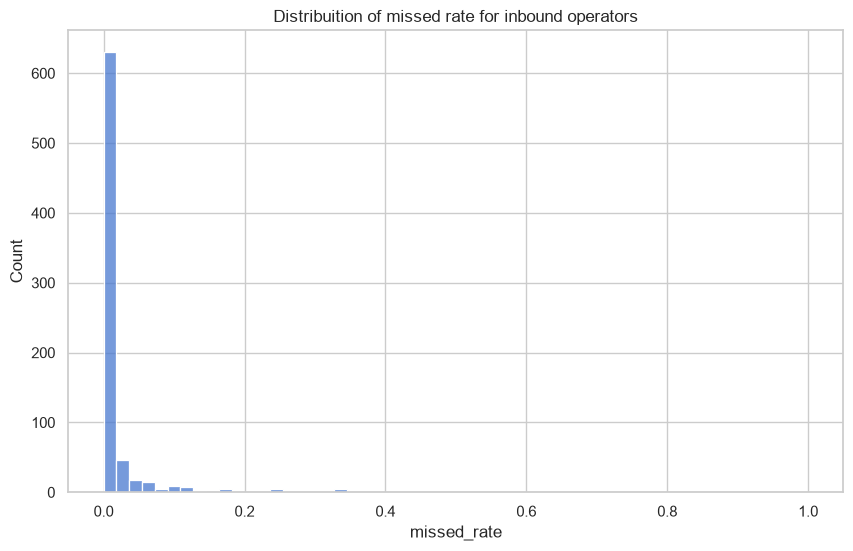

In [58]:
# visualização distribuição da taxa de chamadas perdidas por operador
sns.histplot(data=op_missed_ratio['missed_rate'])
plt.title('Distribuition of missed rate for inbound operators')
plt.show()

In [72]:
# descoberta características sobre taxa de chamadas perdidas
op_missed_ratio['missed_rate'].describe(percentiles=[.25, .50, .75, .85, .90, .95])

count   754.00
mean      0.02
std       0.07
min       0.00
25%       0.00
50%       0.00
75%       0.01
85%       0.02
90%       0.04
95%       0.09
max       1.00
Name: missed_rate, dtype: float64

75% dentre todos os 754 operadores inbound, possui taxa de chamadas perdidas inferior a 1%.

O caso mais extremo é de um operador com taxa de chamadas perdidas a 100%.

Dentre os 239 operadores que possuem taxa de chamadas perdidas superior a 0, até 75% destes estão abaixo de 5%.

#### Distribuição mediana do tempo de espera por operador inbound

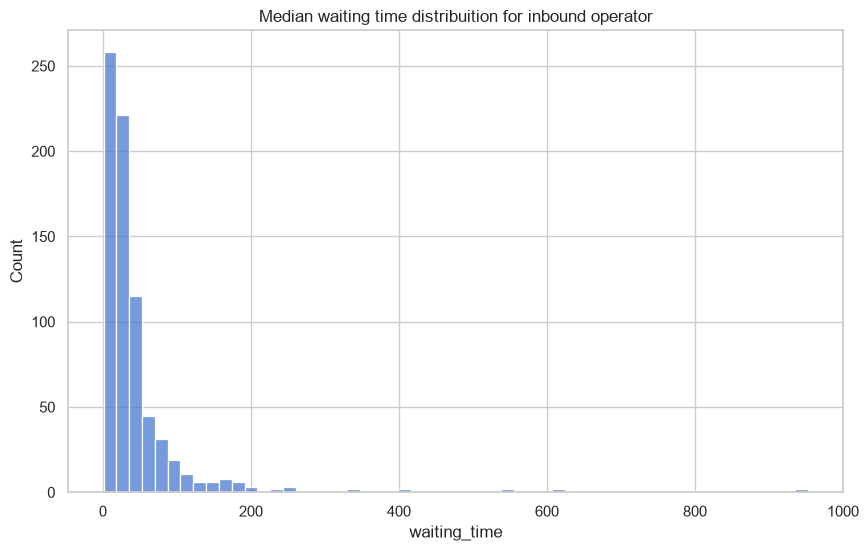

In [62]:
# visualização distribuição mediana do tempo de espera 
sns.histplot(telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['waiting_time'].median())
plt.title('Median waiting time distribuition for inbound operator')
plt.show()

In [73]:
# descoberta características sobre mediana do tempo de espera
telecom_ops[telecom_ops['direction'] == 'in'].groupby('operator_id')['waiting_time'].median().describe(percentiles=[.25, .50, .75, .85, .90, .95])

count   754.00
mean     50.38
std      90.89
min       1.00
25%      15.00
50%      25.00
75%      48.00
85%      71.02
90%      94.35
95%     170.35
max     953.00
Name: waiting_time, dtype: float64

Dentre todos os 754 operadores inbound, metade deles possue mediana do tempo de espera inferior a 25s. Enquanto o Q3 está em 48s (~2x superior a mediana).

O caso mais extremo é de um operador com a mediana do tempo de espera em 953s, valor ~38x superior ao observado dentre a mediana dos operadores.

### Síntese da EDA

A análise exploratória revela quatro padrões estruturais que orientam a avaliação de operadores:

**1. Concentração de volume extrema** -
Tanto em inbound como outbound, a distribuição de chamadas por operador é fortemente assimétrica. A maioria dos operadores tem volume baixo (mediana inbound: 17 chamadas; mediana outbound: 90 chamadas), enquanto um número reduzido de operadores concentra volumes muito superiores. Isto justifica a um inclusão de critério de volume mínimo a um operador na avaliação.

**2. Missed rate inbound concentrada em valores baixos** -
75% dos 754 operadores inbound têm taxa de chamadas perdidas inferior a 1%. Os operadores com desvio relevante são uma minoria — o que torna a identificação de outliers mais precisa e reduz o risco de falsos positivos.

**3. Waiting time com cauda longa** -
A mediana de `waiting_time` entre operadores inbound é de 22 segundos, mas o Q3 já está em 42 segundos e o caso extremo atinge 578 segundos. A distribuição justifica o uso de medianas (em vez de médias) e de thresholds baseados em percentis na avaliação.

**4. Estrutura de empresas predominantemente pequena** - 
Metade das empresas-cliente tem ≤ 2 operadores inbound/outbound activos no período. Equipas pequenas aumentam a sensibilidade da avaliação: comparações estatísticas entre um operador e a sua equipa tornam-se menos estáveis com amostras reduzidas. Este facto é documentado como limitação da análise, não como critério de exclusão.

**5. Crescimento acelerado** -
o volume de chamadas cresceu ~10x de agosto a novembro, puxado pelo outbound. Isso aumenta a relevância da análise de produtividade.

**6. Assimetria estrutural dos nulos** - 
27.3% das chamadas perdidas não têm operador associado, o que limita a análise a chamadas efectivamente atribuídas.

# **Cálculo KPIs e Identificação de Ineficiência**

## Definição de KPIs

### KPI 1 — Missed Rate (inbound)

Fórmula: total chamadas inbound perdidas do operador / total de chamadas inboud recebidas.

Para comparação de proporções entre operador e equipe (sem o trabalhador).

Critérios de identificação de ineficiência (todos devem ser satisfeitos):

**1. Volume mínimo — P25 local por equipa**

Um threshold global ignoraria a diferença de escala entre empresas. O volume mínimo é definido com base na distribuição da equipa em que o operador está inserido:

- Equipas com ≥ 3 operadores: operador deve atingir o P25 do volume de chamadas inbound da sua equipa
- Equipas com 2 operadores: o operador com menor volume deve ter pelo menos 75% do volume do colega
- Equipas com 1 operador: excluídos da avaliação por ausência de grupo de referência válido. A comparação com operadores de outras empresas não é aplicável — o contexto operacional varia entre clientes.

**2. Significância estatística: p < 0.05**

Teste: Z-test de duas proporções (operador vs. restante da equipa)

**3. Operador acima do P85 da distribuição de missed_rate da equipa**

P85 verificado em EDA para operadores globalmente: 0.02 (2%). Separa variação natural de outliers com base na distribuição observada na EDA (mediana global: 0.00 e Q3 0.01).

### KPI 2 — Waiting Time (inbound)

Fórmula: mediana do tempo de espera do operador (total_call_duration - call_duration)

Critérios de identificação de ineficiência (todos devem ser satisfeitos):

**1. Volume mínimo — P25 local por equipa**

Mesma lógica do KPI 1:

- Equipas com ≥ 3 operadores: operador deve atingir o P25 do volume de chamadas inbound da sua equipa
- Equipas com 2 operadores: o operador com menor volume deve ter pelo menos 75% do volume do colega
- Equipas com 1 operador: excluídos da avaliação por ausência de grupo de referência válido.

**2. Significância estatística: p < 0.05**

Teste: Mann-Whitney U (operador vs. restante da equipa) Justificação: distribuição de waiting_time confirmada como fortemente assimétrica na EDA — teste não-paramétrico adequado.

**3. Operador acima do P85 da distribuição de medianas da equipa**

P85 verificado em EDA para operadores globalmente: 71 segundos. Separa variação natural de outliers com base na distribuição observada na EDA (mediana global: 25s, Q3: 48s).

### KPI 3 — Produtividade Outbound


#### Observação produtividade outbound a nível semanal

In [75]:
# mediana semanal de chamadas outbound por operador
weekly_outbound = (
    telecom_ops[telecom_ops['direction'] == 'out']
    .groupby(['operator_id', 'week'])['calls_count']
    .sum()
    .reset_index()
)

op_weekly_median = weekly_outbound.groupby('operator_id')['calls_count'].median()
op_weekly_median.describe(percentiles=[.05, .10, .15, .20, .25, .30, .35, .40, .45, .50, .75])

count    882.00
mean     107.14
std      317.14
min        1.00
5%         1.00
10%        1.05
15%        2.00
20%        3.00
25%        4.00
30%        5.00
35%        7.00
40%        9.00
45%       12.00
50%       16.00
75%       85.75
max     5191.00
Name: calls_count, dtype: float64

In [ ]:
# proporção de chamadas outbound vs total por operador
telecom_ops.groupby('operator_id').apply(
    lambda g: g[g['direction'] == 'out']['calls_count'].sum() / g['calls_count'].sum()
).describe()

count   1092.00
mean       0.64
std        0.40
min        0.00
25%        0.25
50%        0.83
75%        1.00
85%        1.00
max        1.00
dtype: float64

In [ ]:
# operadores com proporção outbound >= 66%
op_proportion = telecom_ops.groupby('operator_id').apply(
    lambda g: g[g['direction'] == 'out']['calls_count'].sum() / g['calls_count'].sum()
)
print(f'Operadores com proporção outbound >= 66%: {(op_proportion >= 0.66).sum()}')
print(f'Total de operadores: {len(op_proportion)}')
ops_outbound = op_proportion[op_proportion >= 0.66].index

Operadores com proporção outbound >= 66%: 662
Total de operadores: 1092


In [ ]:
# mediana semanal restrita a esses operadores
weekly_outbound = (
    telecom_ops[
        (telecom_ops['direction'] == 'out') &
        (telecom_ops['operator_id'].isin(ops_outbound))
    ]
    .groupby(['operator_id', 'week'])['calls_count']
    .sum()
    .reset_index()
)

op_weekly_median = weekly_outbound.groupby('operator_id')['calls_count'].median()
op_weekly_median.describe(percentiles=[.10, .15, .20, .25, .50, .75])

count    662.00
mean     135.29
std      360.52
min        1.00
10%        2.00
15%        3.00
20%        5.00
25%        6.00
50%       28.00
75%      133.62
max     5191.00
Name: calls_count, dtype: float64

#### Classificação

Fórmula: mediana semanal de chamadas outbound do operador

Critérios de identificação de ineficiência (todos devem ser satisfeitos):

**1. Critério de inclusão — proporção outbound ≥ 66%**

Apenas operadores com pelo menos 66% das suas chamadas no sentido outbound são avaliados neste KPI (A cada três chamadas, ao menos 2 são outbound).
Justificação: avaliar produtividade outbound de operadores com função predominantemente inbound não é metodologicamente defensável. Operadores no escopo: 662 de 1092 (~60.6%)

**2. Volume mínimo — P25 local por equipa**

Mesma lógica dos KPIs 1 e 2:

- Equipas com ≥ 3 operadores: operador deve atingir o P25 do volume semanal de chamadas outbound da sua equipa
- Equipas com 2 operadores: o operador com menor volume deve ter pelo menos 75% do volume do colega
- Equipas com 1 operador: excluídos da avaliação por ausência de grupo de referência válido.

**3. Significância estatística: p < 0.05**

Teste: Mann-Whitney U (operador vs. restante da equipa) Justificação: distribuição de calls_count confirmada como fortemente assimétrica na EDA — teste não-paramétrico adequado.

**4. Operador abaixo do P15 da distribuição de medianas semanais da equipa**

P15 verificado em EDA para operadores globalmente (662 operadores com proporção outbound ≥ 66%): 3 chamadas/semana. Identifica operadores na cauda inferior da distribuição de produtividade dentro da sua equipa.